# final-rotation-2 on strongly rotated wings

Random held-out test wings, each rotated by a random angle (one per equal-width angle bin, so the whole circle is covered), then run through the full pipeline: model → landmarks → GPA ordering.

Circles = ground truth, dots = prediction, colour = landmark index. A dot inside its own-coloured circle means correct position *and* identity.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import tv_tensors
from torchvision.transforms import v2

from wings.config import COUNTRIES, MODELS_DIR, PROCESSED_DATA_DIR
from wings.dataset import WingsRawDataset
from wings.gpa import FULL_ROTATION_MULTISTART_ANGLES, handle_coordinates
from wings.modeling.litnet import LitNet
from wings.modeling.loss import BCEDiceLoss
from wings.modeling.unet import UNet
from wings.visualizing.image_preprocess import final_coords, unet_fit_rectangle_preprocess

SEED = 0  # change to draw different wings and angles
N = 16  # wings to draw (one random angle per 360/N degree bin)
PER_FIGURE = 4  # wings per figure (2 x 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mean_coords = torch.load(PROCESSED_DATA_DIR / "mask_datasets" / "rectangle" / "mean_shape.pth", weights_only=False)

unet = UNet(in_channels=1, out_channels=1, kernel_size=5, sigmoid=False)
model = LitNet.load_from_checkpoint(
    MODELS_DIR / "final" / "final-rotation-2.ckpt", model=unet, criterion=BCEDiceLoss(), strict=False
).eval().to(device)

raw_ds = WingsRawDataset(COUNTRIES, PROCESSED_DATA_DIR / "cropped")
_, _, test_set = raw_ds.split(0.2, 0.1, seed=42)
print(f"Test wings: {len(test_set)}")

2026-10-03 12:25:06.962 | INFO     | wings.config:<module>:44 - PROJ_ROOT path is: C:\Users\X\projects\bees


2026-10-03 12:25:07.811 | INFO     | wings.config:<module>:68 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'


W1003 12:25:09.508000 25764 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


  0%|          | 0/21722 [00:00<?, ?it/s]

 52%|█████▏    | 11352/21722 [00:00<00:00, 113400.88it/s]

100%|██████████| 21722/21722 [00:00<00:00, 113159.08it/s]

Test wings: 2172


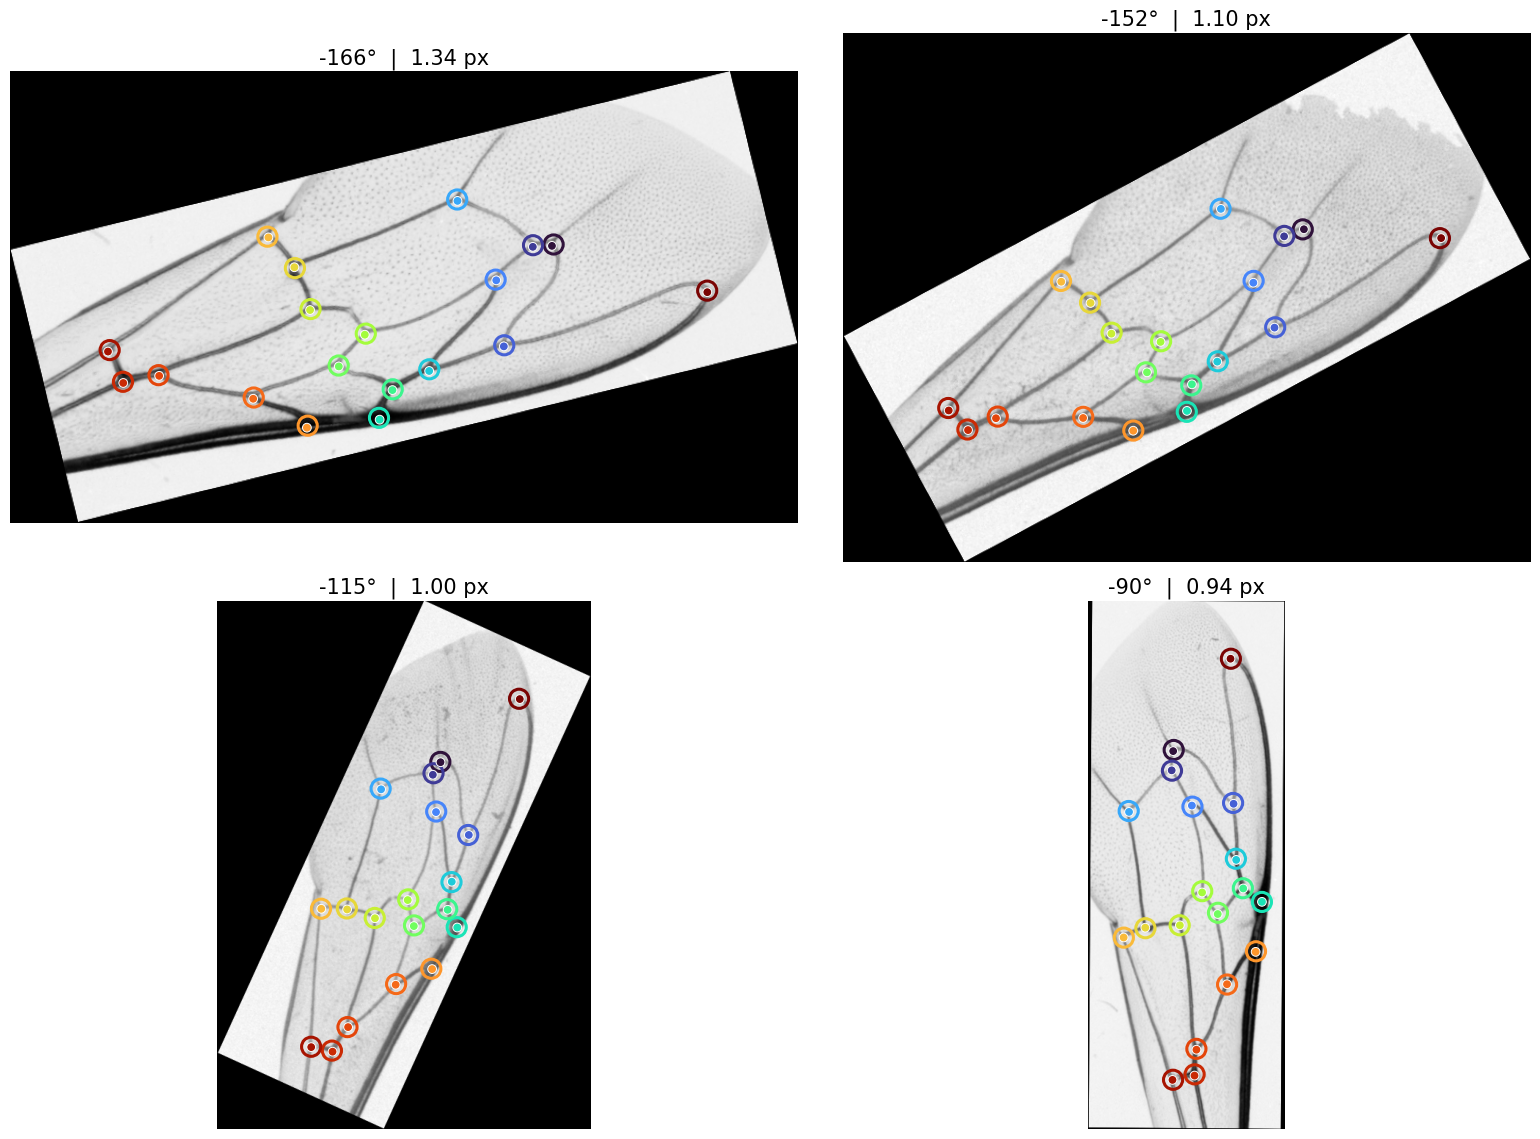

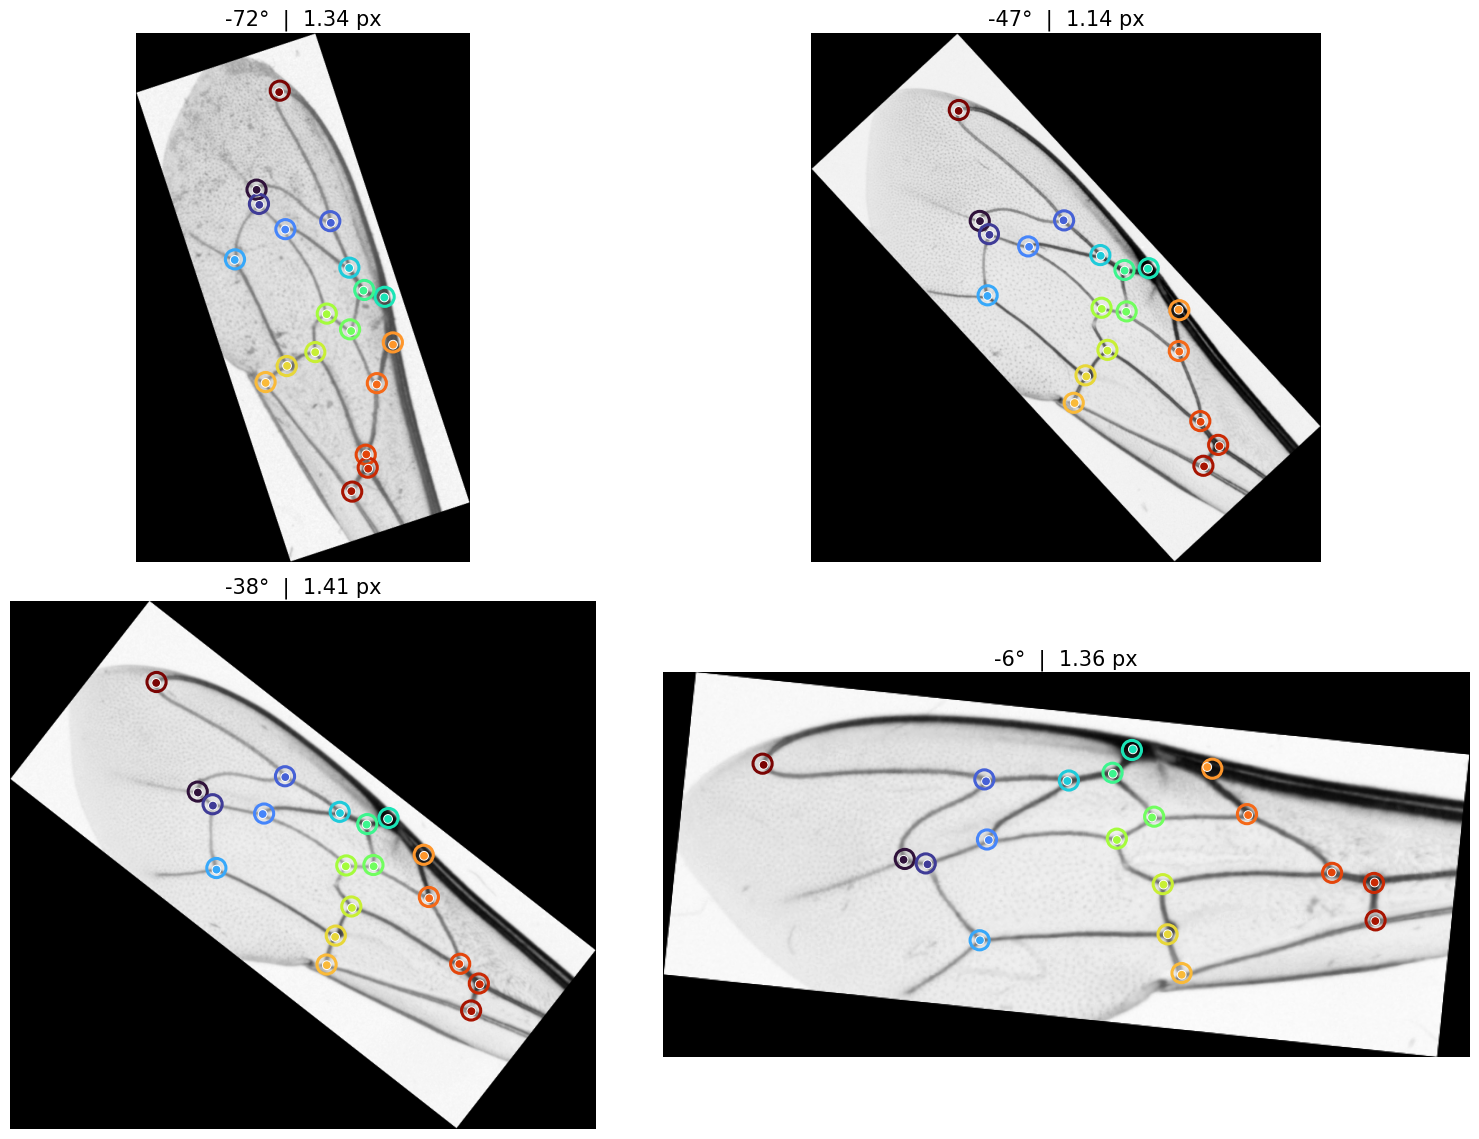

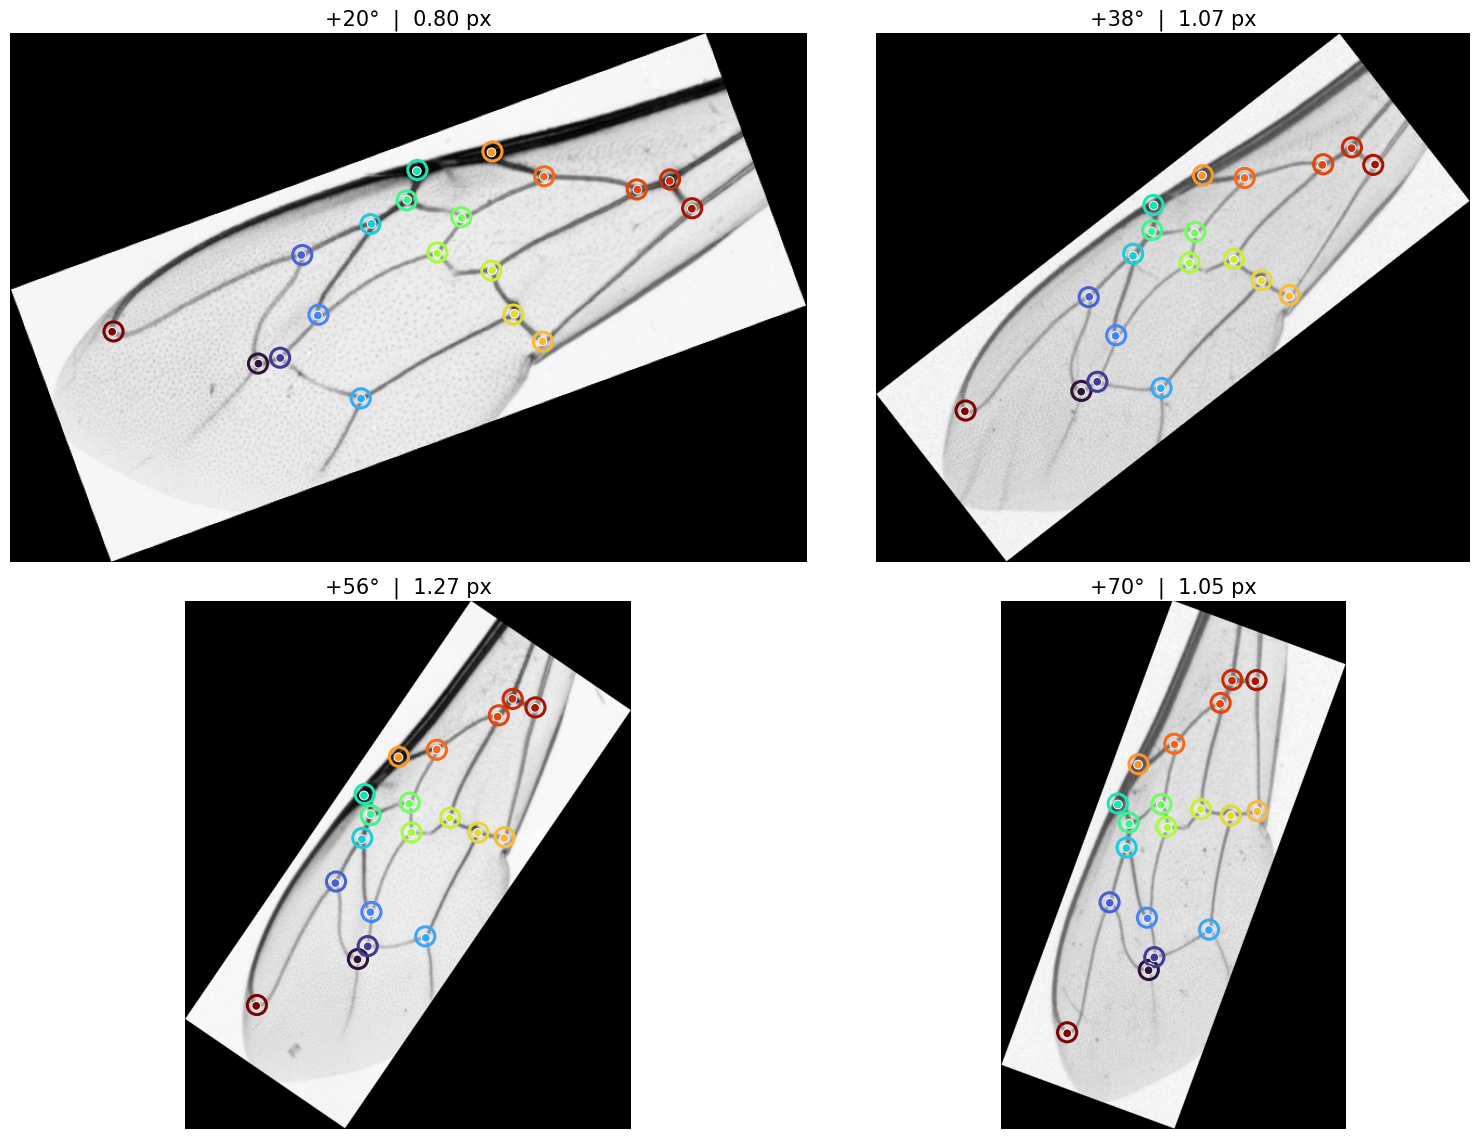

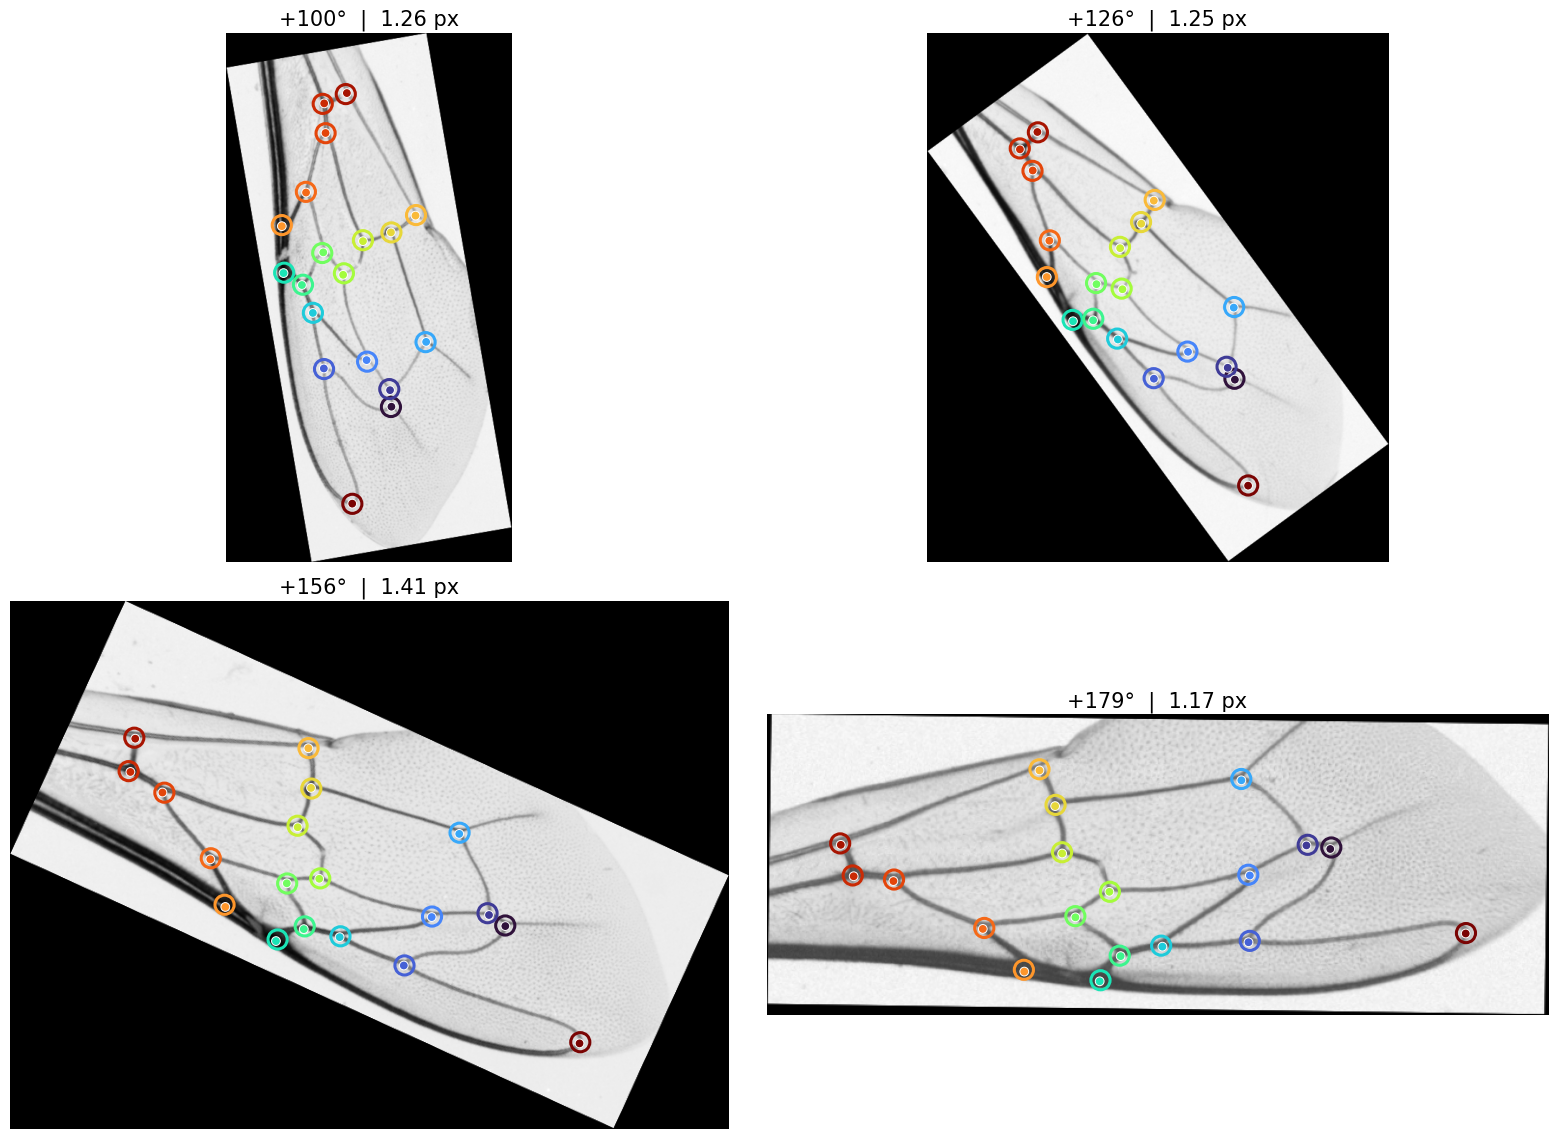

Mean error over these 16 wings: 1.18 px


In [2]:
def predict(img):
    """(1, H, W) uint8 -> 19 GPA-ordered landmarks (bottom-left pixel coords) and the raw detected point count."""
    _, h, w = img.shape
    x, _, _ = unet_fit_rectangle_preprocess(img, output_size=400)
    with torch.no_grad():
        probs = torch.sigmoid(model(x.unsqueeze(0).to(device)))
    mask = (probs > 0.5).float().squeeze().cpu().numpy()
    raw = torch.tensor(final_coords(mask, w, h), dtype=torch.float32)
    ordered = handle_coordinates(
        raw, mean_coords, allow_reflection=True,
        multistart_angles=FULL_ROTATION_MULTISTART_ANGLES, pca_prealign=True,
    )
    return ordered, len(raw)


rng = random.Random(SEED)
idxs = rng.sample(range(len(test_set)), N)
bin_width = 360 / N
angles = [-180 + bin_width * k + rng.uniform(0, bin_width) for k in range(N)]

colors = plt.cm.turbo(np.linspace(0, 1, 19))
errors = []
for start in range(0, N, PER_FIGURE):
    fig, axes = plt.subplots(2, PER_FIGURE // 2, figsize=(8 * (PER_FIGURE // 2), 11.5))
    for ax, idx, angle in zip(axes.flat, idxs[start:start + PER_FIGURE], angles[start:start + PER_FIGURE]):
        image, label, (w, h) = test_set[idx]
        keypoints = torch.stack([label[::2].float(), h - label[1::2].float() - 1], dim=-1)  # top-left (x, y)

        rotate = v2.RandomRotation(degrees=(angle, angle), expand=True, interpolation=v2.InterpolationMode.BILINEAR)
        rot_img, rot_kp = rotate(tv_tensors.Image(image), tv_tensors.KeyPoints(keypoints, canvas_size=(h, w)))
        rot_img, rot_kp = rot_img.as_subclass(torch.Tensor), rot_kp.as_subclass(torch.Tensor)
        rot_h = rot_img.shape[1]

        pred, n_raw = predict(rot_img)
        pred_xy = torch.stack([pred[:, 0], rot_h - pred[:, 1] - 1], dim=-1)  # back to top-left for plotting
        error = torch.norm(pred_xy - rot_kp, dim=1).mean().item()
        errors.append(error)

        ax.imshow(rot_img.squeeze(0).numpy(), cmap="gray")
        ax.scatter(rot_kp[:, 0], rot_kp[:, 1], s=190, facecolors="none", edgecolors=colors, linewidths=2.2)
        ax.scatter(pred_xy[:, 0], pred_xy[:, 1], s=40, c=colors, edgecolors="white", linewidths=0.7)
        ax.set_title(
            f"{angle:+.0f}°  |  {error:.2f} px" + ("" if n_raw == 19 else f"  |  {n_raw} pts detected"), fontsize=15
        )
        ax.axis("off")
    plt.tight_layout()
    plt.show()
print(f"Mean error over these {N} wings: {np.mean(errors):.2f} px")